## Import bibliotek

In [6]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import geopandas as gpd

pd.set_option("display.max_columns", 30)
pd.set_option('display.max_rows', None)

## Wczytanie danych dotyczących aptek
Wczytanie danych ze strony https://rejestry.ezdrowie.gov.pl/registry/ra z dnia `21.04.2026`

In [51]:
df = pd.read_csv("data/Rejestr_Aptek_stan_na_dzien_2026-04-21.csv", encoding="utf-8-sig", sep="|", low_memory=False)

## Wstępna analiza
Analizie poddane będą aktywne `Apteki Ogólnodostępne` oraz `Punkty Apteczne` 

In [55]:
df = df[["identyfikator_apteki", "stan_apteki", "rodzaj_apteki", "wojewodztwo"]]

In [56]:
df["wojewodztwo"] = df["wojewodztwo"].str.strip().str.upper().str.replace(" ", "-")

In [57]:
df = df[(df["stan_apteki"] == "AKTYWNA") & (df["rodzaj_apteki"].isin(["APTEKA OGÓLNODOSTĘPNA", "PUNKT APTECZNY"]))]
df.head()

,identyfikator_apteki,stan_apteki,rodzaj_apteki,wojewodztwo
2,1000031,AKTYWNA,APTEKA OGÓLNODOSTĘPNA,ŚWIĘTOKRZYSKIE
3,1000044,AKTYWNA,APTEKA OGÓLNODOSTĘPNA,ŚWIĘTOKRZYSKIE
6,1000077,AKTYWNA,APTEKA OGÓLNODOSTĘPNA,ŚWIĘTOKRZYSKIE
9,1000106,AKTYWNA,PUNKT APTECZNY,ŚWIĘTOKRZYSKIE
10,1000111,AKTYWNA,APTEKA OGÓLNODOSTĘPNA,ŚWIĘTOKRZYSKIE


In [59]:
df_apteki = df.groupby("wojewodztwo").size().reset_index(name="apteki")
df_apteki  # ilość aptek według województwa

,wojewodztwo,apteki
0,DOLNOŚLĄSKIE,899
1,KUJAWSKO-POMORSKIE,641
2,LUBELSKIE,736
3,LUBUSKIE,303
4,MAZOWIECKIE,1650
5,MAŁOPOLSKIE,1090
6,OPOLSKIE,298
7,PODKARPACKIE,694
8,PODLASKIE,402
9,POMORSKIE,674


## Wczytanie danych dotyczących ludności 
Wczytanie danych ze strony https://bdl.stat.gov.pl/bdl/start z podziałem na województwa w Polsce 

## Wstpna analiza
Analizowane będą dane dla liczby `ludności ogółem` oraz dla `seniorów 70+`

In [60]:
df_ludnosc = pd.read_csv("data/LUDN_2137_CTAB_20260414235116.csv", encoding="utf-8", sep=";")

In [61]:
df_ludnosc = df_ludnosc.rename({'Nazwa': 'wojewodztwo', 'ogółem;ogółem;2024;[osoba]': 'ludnosc', '70 i więcej;ogółem;2024;[osoba]': "seniorzy_70plus" }, axis=1)

In [71]:
df_ludnosc = df_ludnosc[["wojewodztwo", "ludnosc", "seniorzy_70plus"]]
df_ludnosc

,wojewodztwo,ludnosc,seniorzy_70plus
0,DOLNOŚLĄSKIE,2868242,416508
1,KUJAWSKO-POMORSKIE,1984479,276273
2,LUBELSKIE,1996440,293986
3,LUBUSKIE,969819,134377
4,ŁÓDZKIE,2345924,367885
5,MAŁOPOLSKIE,3429084,440656
6,MAZOWIECKIE,5508322,738206
7,OPOLSKIE,930296,135359
8,PODKARPACKIE,2062997,274002
9,PODLASKIE,1132641,156076


In [64]:
df_final = df_apteki.merge(df_ludnosc, on="wojewodztwo")

In [65]:
df_final["apteki_na_100k"] = (df_final["apteki"] / df_final["ludnosc"] * 100000).round().astype(int)

In [66]:
df_final["apteki_na_100k_70plus"] = (df_final["apteki"] / df_final["seniorzy_70plus"] * 100000).round().astype(int)

In [67]:
df_final

,wojewodztwo,apteki,ludnosc,seniorzy_70plus,apteki_na_100k,apteki_na_100k_70plus
0,DOLNOŚLĄSKIE,899,2868242,416508,31,216
1,KUJAWSKO-POMORSKIE,641,1984479,276273,32,232
2,LUBELSKIE,736,1996440,293986,37,250
3,LUBUSKIE,303,969819,134377,31,225
4,MAZOWIECKIE,1650,5508322,738206,30,224
5,MAŁOPOLSKIE,1090,3429084,440656,32,247
6,OPOLSKIE,298,930296,135359,32,220
7,PODKARPACKIE,694,2062997,274002,34,253
8,PODLASKIE,402,1132641,156076,35,258
9,POMORSKIE,674,2359493,302750,29,223


In [33]:
top6 = df_final.sort_values("apteki_na_100k", ascending=False).head(6)
top6

,wojewodztwo,apteki,ludnosc,seniorzy_70plus,apteki_na_100k,apteki_na_100k_70plus
2,LUBELSKIE,736,1996440,293986,37,250
11,WIELKOPOLSKIE,1272,3479986,448780,37,283
13,ŁÓDZKIE,841,2345924,367885,36,229
12,ZACHODNIOPOMORSKIE,560,1622760,236717,35,237
8,PODLASKIE,402,1132641,156076,35,258
7,PODKARPACKIE,694,2062997,274002,34,253


In [34]:
top6_70plus = df_final.sort_values("apteki_na_100k_70plus", ascending=False).head(6)
top6_70plus

,wojewodztwo,apteki,ludnosc,seniorzy_70plus,apteki_na_100k,apteki_na_100k_70plus
11,WIELKOPOLSKIE,1272,3479986,448780,37,283
8,PODLASKIE,402,1132641,156076,35,258
7,PODKARPACKIE,694,2062997,274002,34,253
2,LUBELSKIE,736,1996440,293986,37,250
5,MAŁOPOLSKIE,1090,3429084,440656,32,247
12,ZACHODNIOPOMORSKIE,560,1622760,236717,35,237


In [35]:
bottom6 = df_final.sort_values("apteki_na_100k").head(6)
bottom6

,wojewodztwo,apteki,ludnosc,seniorzy_70plus,apteki_na_100k,apteki_na_100k_70plus
10,WARMIŃSKO-MAZURSKIE,391,1349172,177620,29,220
9,POMORSKIE,674,2359493,302750,29,223
4,MAZOWIECKIE,1650,5508322,738206,30,224
0,DOLNOŚLĄSKIE,899,2868242,416508,31,216
3,LUBUSKIE,303,969819,134377,31,225
14,ŚLĄSKIE,1313,4291441,636213,31,206


In [36]:
bottom5_70plus = df_final.sort_values("apteki_na_100k_70plus").head(6)
bottom5_70plus

,wojewodztwo,apteki,ludnosc,seniorzy_70plus,apteki_na_100k,apteki_na_100k_70plus
14,ŚLĄSKIE,1313,4291441,636213,31,206
15,ŚWIĘTOKRZYSKIE,385,1157991,182578,33,211
0,DOLNOŚLĄSKIE,899,2868242,416508,31,216
6,OPOLSKIE,298,930296,135359,32,220
10,WARMIŃSKO-MAZURSKIE,391,1349172,177620,29,220
9,POMORSKIE,674,2359493,302750,29,223


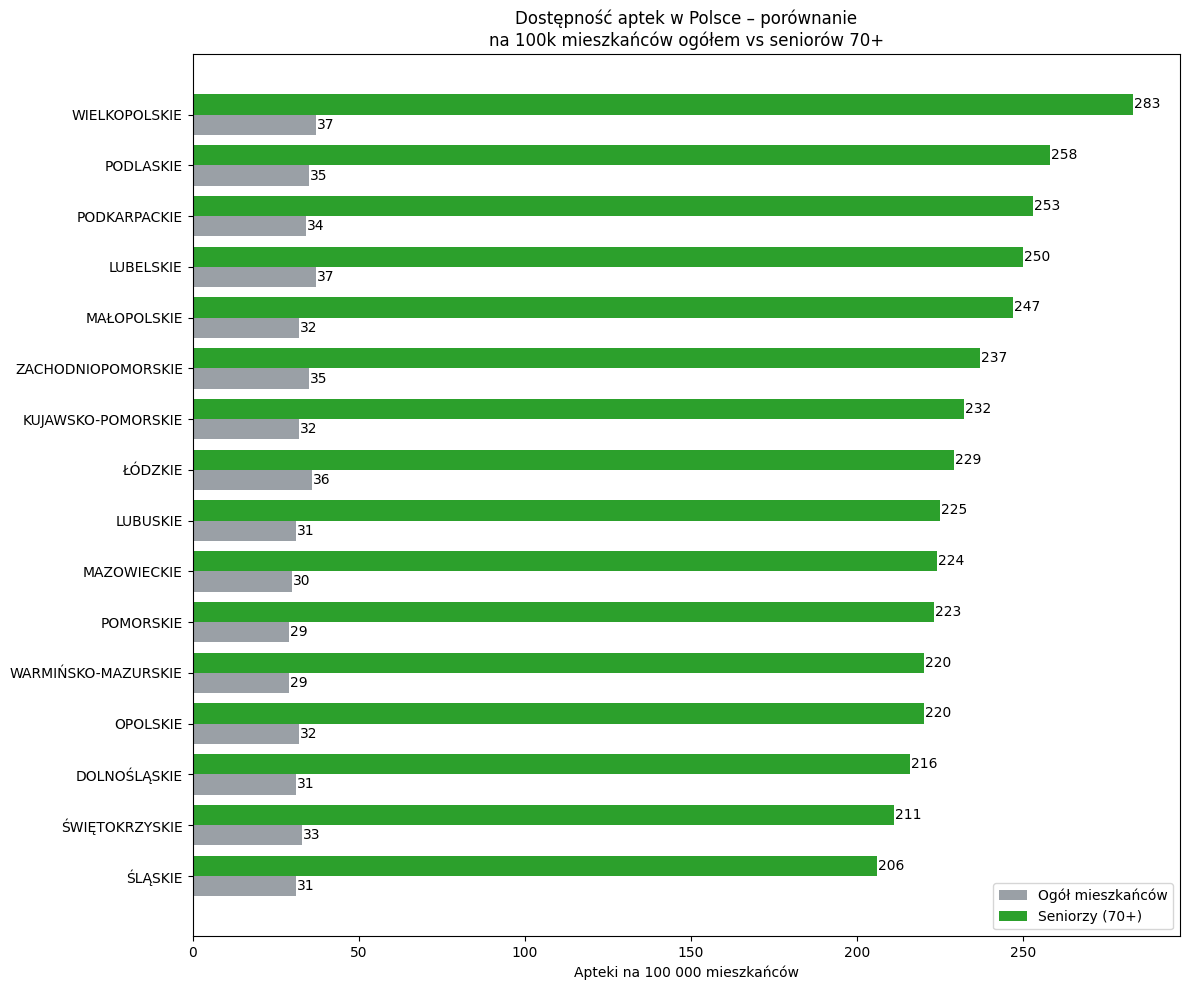

In [37]:
df_plot = df_final.sort_values("apteki_na_100k_70plus")

x = np.arange(len(df_plot))
width = 0.4

plt.figure(figsize=(12, 10))

plt.barh(x - width/2, df_plot["apteki_na_100k"], height=width, label="Ogół mieszkańców", color="#9aa0a6")
plt.barh(x + width/2, df_plot["apteki_na_100k_70plus"], height=width, label="Seniorzy (70+)", color="#2ca02c")

plt.yticks(x, df_plot["wojewodztwo"])

plt.title("Dostępność aptek w Polsce – porównanie\nna 100k mieszkańców ogółem vs seniorów 70+")
plt.xlabel("Apteki na 100 000 mieszkańców")

for i, v in enumerate(df_plot["apteki_na_100k"]):
    plt.text(v + 0.3, i - width/2, f"{v:.0f}", va='center')

for i, v in enumerate(df_plot["apteki_na_100k_70plus"]):
    plt.text(v + 0.3, i + width/2, f"{v:.0f}", va='center')

plt.legend()
plt.tight_layout()
plt.show()

In [72]:
mapa = gpd.read_file("data/wojewodztwa/wojewodztwa.shp")

In [73]:
mapa["wojewodztwo"] = mapa["JPT_NAZWA_"].str.upper()

In [74]:
df_final["roznica"] = (df_final["apteki_na_100k_70plus"] - df_final["apteki_na_100k"])

In [75]:
mapa = mapa.merge(df_final, on="wojewodztwo")

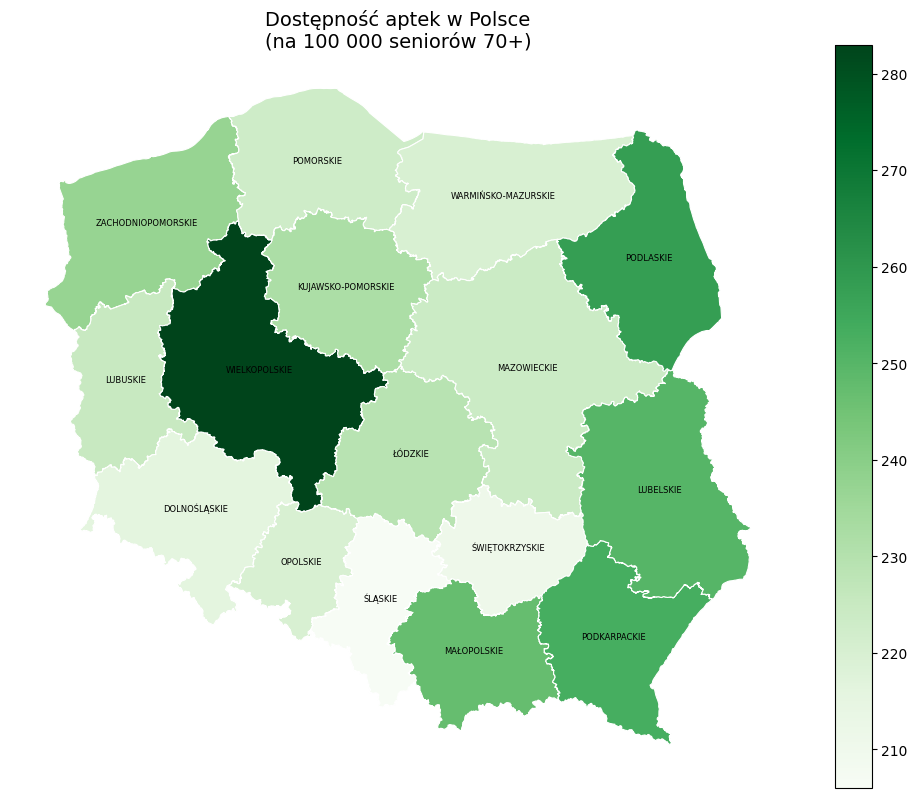

In [76]:
fig, ax = plt.subplots(figsize=(10, 8))

mapa.plot(
    column="apteki_na_100k_70plus",
    cmap="Greens",
    linewidth=0.8,
    edgecolor="white",
    legend=True,
    ax=ax
)

for idx, row in mapa.iterrows():
    plt.text(
        row.geometry.centroid.x,
        row.geometry.centroid.y,
        row["wojewodztwo"],
        fontsize=6,
        ha='center'
    )
    
ax.set_title("Dostępność aptek w Polsce\n(na 100 000 seniorów 70+)", fontsize=14)
ax.axis("off")

plt.tight_layout()
plt.show()

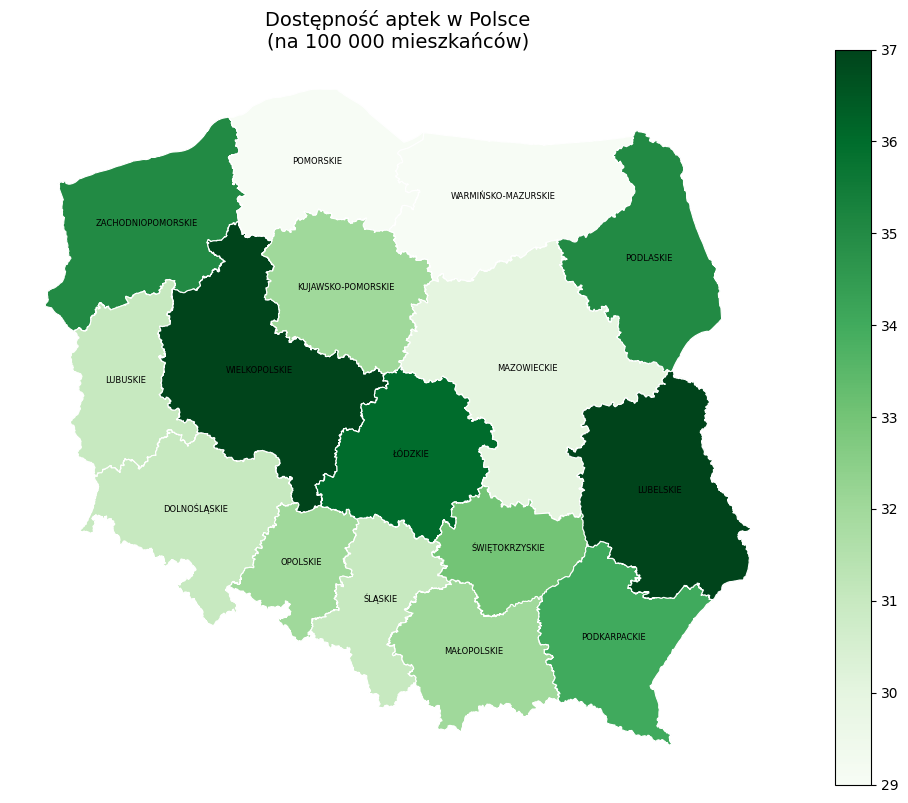

In [77]:
fig, ax = plt.subplots(figsize=(10, 8))

mapa.plot(
    column="apteki_na_100k",
    cmap="Greens",
    linewidth=0.8,
    edgecolor="white",
    legend=True,
    ax=ax
)

for idx, row in mapa.iterrows():
    plt.text(
        row.geometry.centroid.x,
        row.geometry.centroid.y,
        row["wojewodztwo"],
        fontsize=6,
        ha='center'
    )
    
ax.set_title("Dostępność aptek w Polsce\n(na 100 000 mieszkańców)", fontsize=14)
ax.axis("off")

plt.tight_layout()
plt.show()

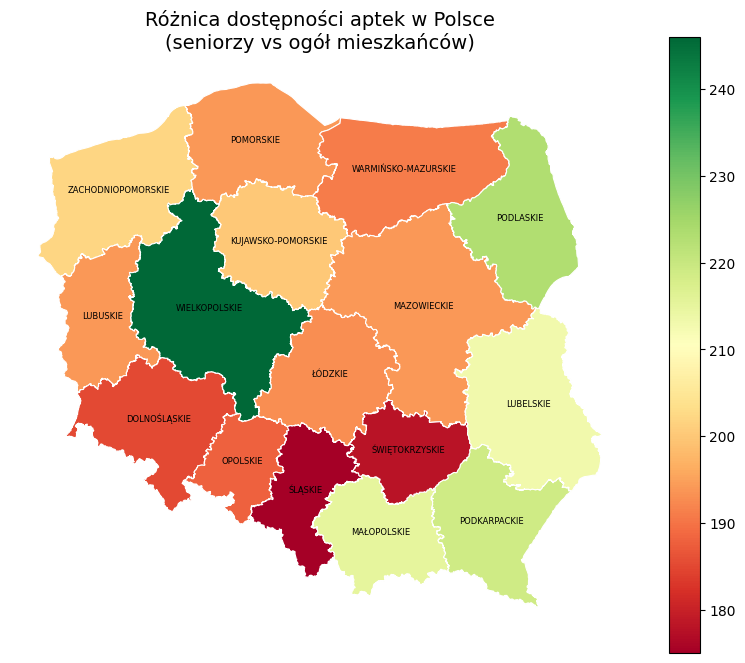

In [78]:
fig, ax = plt.subplots(figsize=(10, 8))

mapa.plot(
    column="roznica",
    cmap="RdYlGn",
    linewidth=0.8,
    edgecolor="white",
    legend=True,
    ax=ax
)

for idx, row in mapa.iterrows():
    plt.text(
        row.geometry.centroid.x,
        row.geometry.centroid.y,
        row["wojewodztwo"],
        fontsize=6,
        ha='center'
    )

ax.set_title("Różnica dostępności aptek w Polsce\n(seniorzy vs ogół mieszkańców)", fontsize=14)
ax.axis("off")

plt.show()

**Wnioski**
- Zróżnicowanie dostępności aptek w przeliczeniu na ogół mieszkańców jest relatywnie niewielkie między województwami.
- W przypadku seniorów (70+) różnice są znacznie większe, co wskazuje na potencjalne nierówności w dostępie do usług farmaceutycznych.
- Seniorzy, jako grupa o większych potrzebach zdrowotnych, powinni mieć relatywnie lepszy dostęp do aptek. Analiza pokazuje jednak, że w części województw dostępność ta nie jest proporcjonalnie wyższa.
- Najwyższy wskaźnik dostępności aptek odnotowano w województwie Wielkopolskim (284 aptek na 100k seniorów), podczas gdy najniższy w województwie Śląskim (206 aptek na 100k seniorów).
- W niektórych regionach dostępność aptek dla seniorów jest wyższa niż dla ogółu mieszkańców, jednak w innych – niższa, co wskazuje na nierównomierne dopasowanie infrastruktury farmaceutycznej.
- Wyniki sugerują, że rozmieszczenie aptek jest bardziej dostosowane do liczby ludności niż do struktury wiekowej, co może prowadzić do niedopasowania dostępności usług dla seniorów.